# Why Adding Useless Features Can Raise Training R2 but Lower Adjusted R2

### A beginner-friendly machine-learning demonstration

In this notebook we run a small, fully controlled experiment.

We build a dataset where **only one feature actually matters** (`study_hours`), and then we keep adding **completely random, meaningless features** (like `shoe_size`) to a Linear Regression model.

We will watch three things happen:

1. **Training R2 never goes down** - it stays the same or creeps up, even though the new features are pure garbage.
2. **Adjusted R2 often goes down** - because it charges a *penalty* for every extra feature.
3. **Test R2 often goes down** - because the model memorised noise instead of learning the real pattern.

Everything is generated with NumPy, so there is **no external dataset and no internet access required**.

## 1. Introduction

### 1.1 What is R2 (R-squared) in simple language?

Imagine you have to guess the marks of every student but you are given **no information at all**. The safest guess is the **average mark** of the class. That is the dumbest reasonable model, and we call it the *baseline*.

R2 answers one question:

> **How much better is my model than just always guessing the average?**

The formula is:

    R2 = 1 - (SS_res / SS_tot)

where

* `SS_res` = sum of squared errors **my model** makes, and
* `SS_tot` = sum of squared errors the **mean-guessing baseline** makes.

Reading the number:

| R2 value | Meaning |
|---|---|
| `1.0` | Perfect - the model explains every wiggle in the data |
| `0.8` | The model removes 80% of the baseline's squared error |
| `0.0` | The model is no better than guessing the mean |
| negative | The model is *worse* than guessing the mean (only possible on unseen data) |

So **R2 measures improvement over predicting the target mean**. It is a *relative* score, not an absolute one.

### 1.2 What is Adjusted R2 in simple language?

Plain R2 has a weakness: it **rewards complexity for free**. Adjusted R2 fixes this by asking a harder question:

> **Is the improvement big enough to be worth the extra feature I had to add?**

The formula is:

    Adjusted R2 = 1 - [ (1 - R2) * (n - 1) / (n - k - 1) ]

where `n` = number of observations and `k` = number of input features.

Look at the `(n - k - 1)` in the denominator. Every time you add a feature, `k` grows, `(n - k - 1)` shrinks, and the quantity being subtracted from 1 gets **bigger**. So Adjusted R2 automatically drops **unless** the new feature raises R2 by a meaningful amount. It is like a membership fee: a new feature must *earn* its place.

### 1.3 Why training R2 can never decrease when you add a feature

This is the key mathematical fact of the whole notebook.

Ordinary Least Squares (OLS) finds the coefficients that make the training squared error **as small as possible**. Now suppose:

* Model A uses features `[study_hours]`.
* Model B uses features `[study_hours, shoe_size]`.

Model B **can always copy Model A exactly** by simply setting the coefficient of `shoe_size` to `0`. That option is available to it. Since OLS picks the *best* option, Model B's training error can never be worse than Model A's - at worst it ties.

Smaller-or-equal training error means **larger-or-equal training R2**. Models like this, where one feature set fully contains the other, are called **nested models**. So:

> For nested OLS models scored on the **same training data**, training R2 can only stay the same or go up. It can never go down.

### 1.4 So why does it actually go *up* for a random feature?

In theory a useless feature deserves a coefficient of exactly `0`. In practice, with a **finite** dataset, a column of random numbers will *by pure accident* line up a little bit with the leftover errors (the residual noise) of the previous model.

Think of flipping 150 coins: you will never get exactly 75 heads every time. Random data always has small accidental patterns. OLS is greedy - it happily grabs that accidental overlap, gives the feature a small non-zero coefficient, and shaves a tiny bit off the training error.

That tiny gain is **fake**. It describes this specific sample's noise, not any real-world rule. That is exactly why it disappears (or backfires) on the test set - and why Adjusted R2 refuses to be impressed by it.

### Import the libraries we need

We import everything once here so that every later cell can be read on its own.

In [1]:
import numpy as np                      # fast maths and random numbers
import pandas as pd                     # tables (DataFrames)
import matplotlib.pyplot as plt          # plotting
import seaborn as sns                    # prettier statistical plots

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make every chart in this notebook look consistent and readable.
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

# Show numbers in tables with 4 decimal places instead of long floats.
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
pd.set_option('display.width', 120)

print('All libraries imported successfully.')
print('NumPy  version:', np.__version__)
print('pandas version:', pd.__version__)

All libraries imported successfully.
NumPy  version: 2.5.2
pandas version: 3.0.5


## 2. Create a reproducible synthetic dataset

We **invent** the data ourselves. This is the whole point of the experiment: because we wrote the rule that creates `marks`, we know with 100% certainty which features are real and which are junk.

* A fixed random seed (`2396`) means you get exactly the same numbers every time you run this notebook.
* `study_hours` is the **only** genuinely useful feature.
* `marks = 30 + 6 * study_hours + random_noise` is the true rule of our little universe.
* `shoe_size`, `random_feature_1` ... `random_feature_4` are **irrelevant**: they are drawn from their own independent random distributions and are *never* used to build `marks`.

In [2]:
# ---------------------------------------------------------------------------
# Step 1: fix the random seed so the experiment is perfectly reproducible.
# ---------------------------------------------------------------------------
RANDOM_SEED = 2396
N_SAMPLES = 150                      # comfortably more than the required 100
rng = np.random.default_rng(RANDOM_SEED)

# ---------------------------------------------------------------------------
# Step 2: the ONE genuinely useful feature - hours studied per week.
# ---------------------------------------------------------------------------
study_hours = rng.uniform(low=1.0, high=10.0, size=N_SAMPLES)

# ---------------------------------------------------------------------------
# Step 3: build the target from study_hours plus unavoidable random noise.
#         noise = everything we cannot measure (mood, sleep, luck, ...).
# ---------------------------------------------------------------------------
noise = rng.normal(loc=0.0, scale=8.0, size=N_SAMPLES)
marks = 30 + 6 * study_hours + noise

# ---------------------------------------------------------------------------
# Step 4: five IRRELEVANT features, generated independently.
#         Notice that none of them appears in the line that created `marks`.
# ---------------------------------------------------------------------------
shoe_size        = rng.normal(loc=8.0, scale=1.5, size=N_SAMPLES)
random_feature_1 = rng.normal(loc=0.0, scale=1.0, size=N_SAMPLES)
random_feature_2 = rng.normal(loc=0.0, scale=1.0, size=N_SAMPLES)
random_feature_3 = rng.uniform(low=-3.0, high=3.0, size=N_SAMPLES)
random_feature_4 = rng.normal(loc=50.0, scale=10.0, size=N_SAMPLES)

# ---------------------------------------------------------------------------
# Step 5: collect everything into one tidy table.
# ---------------------------------------------------------------------------
df = pd.DataFrame({
    'study_hours': study_hours,
    'shoe_size': shoe_size,
    'random_feature_1': random_feature_1,
    'random_feature_2': random_feature_2,
    'random_feature_3': random_feature_3,
    'random_feature_4': random_feature_4,
    'marks': marks,
})

# Names we will reuse throughout the notebook.
TARGET = 'marks'
USEFUL_FEATURES = ['study_hours']
IRRELEVANT_FEATURES = [
    'shoe_size',
    'random_feature_1',
    'random_feature_2',
    'random_feature_3',
    'random_feature_4',
]
ALL_FEATURES = USEFUL_FEATURES + IRRELEVANT_FEATURES

print('Dataset shape (rows, columns):', df.shape)
print('Target               :', TARGET)
print('Useful feature(s)    :', USEFUL_FEATURES)
print('Irrelevant feature(s):', IRRELEVANT_FEATURES)

Dataset shape (rows, columns): (150, 7)
Target               : marks
Useful feature(s)    : ['study_hours']
Irrelevant feature(s): ['shoe_size', 'random_feature_1', 'random_feature_2', 'random_feature_3', 'random_feature_4']


In [3]:
# The first few rows - a quick look at the raw data.
display(df.head(10).round(4))

,study_hours,shoe_size,random_feature_1,random_feature_2,random_feature_3,random_feature_4,marks
0,7.2619,8.6009,0.9898,-0.7375,0.7473,49.5384,81.5966
1,5.1322,7.3988,0.4439,-0.1521,-0.9946,68.7084,52.6049
2,6.2976,8.8246,-0.2292,0.1688,0.5543,59.9126,64.2835
3,7.7545,8.6377,0.8526,0.1350,1.6673,34.1485,91.3171
4,8.6455,9.2515,0.6171,-0.8514,1.3661,64.4391,87.3872
5,3.3625,8.2022,1.5655,1.0397,1.7303,45.9374,47.1624
6,4.5455,7.1217,-0.6054,-0.4174,0.3936,55.2037,68.4867
7,4.9932,7.8369,0.9112,1.2097,-2.1369,72.9197,59.6739
8,8.3405,9.4566,-0.2555,-0.3811,-2.9700,49.2642,85.1103
9,4.0800,7.7436,0.1417,-1.2651,2.7101,50.5785,57.4151


In [4]:
# Summary statistics: count, mean, standard deviation, min, quartiles, max.
display(df.describe().round(4))

,study_hours,shoe_size,random_feature_1,random_feature_2,random_feature_3,random_feature_4,marks
count,150.0000,150.0000,150.0000,150.0000,150.0000,150.0000,150.0000
mean,5.4410,8.1004,0.0650,-0.1607,-0.1398,50.6869,63.8096
std,2.3829,1.3225,0.9364,1.1628,1.7161,9.4516,16.6310
min,1.2052,4.8023,-2.6717,-2.4487,-2.9700,27.4119,27.3058
25%,3.3665,7.3774,-0.6075,-0.9388,-1.6079,44.9982,51.0951
50%,5.2470,8.1533,0.0994,-0.1787,0.0467,49.5044,63.2157
75%,7.3602,9.0416,0.7642,0.5880,1.0823,56.3504,76.6922
max,9.7797,12.2778,2.3699,3.3673,2.9467,83.5723,108.9368


**What the tables above tell us**

* We have 150 rows and 7 columns (6 inputs + 1 target), so the dataset is small - exactly the situation in which random coincidences are easy to find.
* `study_hours` ranges from about 1 to 10 hours, and `marks` ranges from roughly 27 to 109 with a mean near 64, which is just what `30 + 6 * study_hours + noise` produces.
* The irrelevant columns have completely different scales (`random_feature_4` sits near 50, `random_feature_3` swings between -3 and +3). Scale does not matter for linear regression - what matters is whether a column carries real information. **None of them does.**

## 3. Visualize the real relationship

Before modelling anything, always *look* at the data. A scatter plot of the useful feature against the target should show a clear upward trend.

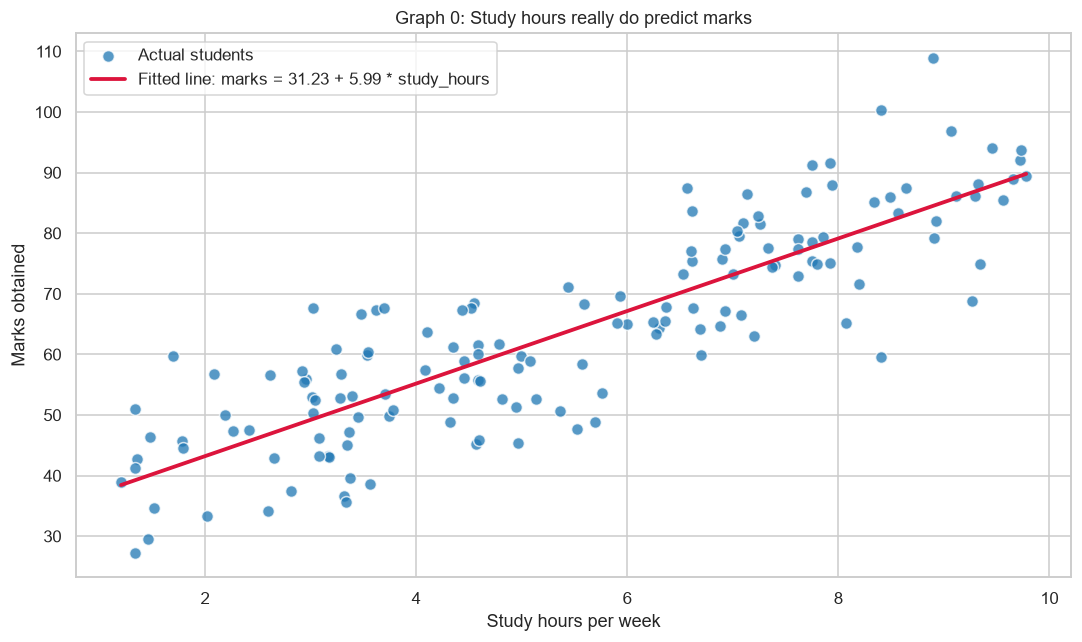

True rule used to build the data : marks = 30.00 + 6.00 * study_hours + noise
Rule recovered by the model      : marks = 31.23 + 5.99 * study_hours
R2 of this single-feature model  : 0.7361


In [5]:
# Fit a simple regression line on the full dataset just for visualisation.
viz_model = LinearRegression()
viz_model.fit(df[['study_hours']], df[TARGET])

# Build a smooth line of x-values so we can draw the fitted straight line.
x_line = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 200)
y_line = viz_model.predict(pd.DataFrame({'study_hours': x_line}))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['study_hours'], df[TARGET],
           color='#1f77b4', alpha=0.75, edgecolor='white', s=60, label='Actual students')
ax.plot(x_line, y_line, color='crimson', linewidth=2.5,
        label=f'Fitted line: marks = {viz_model.intercept_:.2f} + {viz_model.coef_[0]:.2f} * study_hours')

ax.set_xlabel('Study hours per week')
ax.set_ylabel('Marks obtained')
ax.set_title('Graph 0: Study hours really do predict marks')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fitted_r2 = r2_score(df[TARGET], viz_model.predict(df[['study_hours']]))
print('True rule used to build the data : marks = 30.00 + 6.00 * study_hours + noise')
print(f'Rule recovered by the model      : marks = {viz_model.intercept_:.2f} + {viz_model.coef_[0]:.2f} * study_hours')
print(f'R2 of this single-feature model  : {fitted_r2:.4f}')

**Why `study_hours` is a useful predictor**

* The points climb steadily from bottom-left to top-right: more study hours go together with higher marks.
* The red line passes right through the middle of the cloud, and the intercept (~30) and slope (~6) that the model *learned* are very close to the values we *used* to create the data. The model has discovered the real rule.
* The points scatter around the line rather than sitting exactly on it. That vertical spread is the random noise - it is real, unavoidable, and **no feature can ever explain it**. This leftover noise is precisely what our irrelevant features will try to chase in the next sections.

## 4. Train models incrementally

We now train six Linear Regression models on **exactly the same training rows**:

| Model | Features |
|---|---|
| Model 1 | `study_hours` |
| Model 2 | `study_hours` + 1 irrelevant feature |
| Model 3 | `study_hours` + 2 irrelevant features |
| Model 4 | `study_hours` + 3 irrelevant features |
| Model 5 | `study_hours` + 4 irrelevant features |
| Model 6 | `study_hours` + 5 irrelevant features |

Each model's feature list **completely contains** the previous one - these are *nested* models, the exact situation where the "training R2 cannot decrease" rule applies.

**Crucially, we create the train/test split only once** and reuse it for every model. If each model saw a different split, any difference in scores could just be luck of the draw rather than the effect of the extra feature.

### 4.1 The reusable `adjusted_r2(r2, n, k)` function

This is the function required in Section 5. We define it here because Section 4 already needs it.

In [6]:
def adjusted_r2(r2, n, k):
    """Return the Adjusted R-squared score.

    Parameters
    ----------
    r2 : float
        The plain R2 score that was already computed.
    n : int
        Number of observations (rows) used to compute that R2.
    k : int
        Number of input features used by the model.

    Formula
    -------
        Adjusted R2 = 1 - [ (1 - R2) * (n - 1) / (n - k - 1) ]

    The denominator (n - k - 1) must be strictly positive, i.e. n > k + 1.
    """
    n = int(n)
    k = int(k)

    # Validation: with n <= k + 1 the denominator is zero or negative and the
    # formula becomes meaningless (as many knobs as data points).
    if n <= k + 1:
        raise ValueError(
            f'Adjusted R2 needs n > k + 1, but got n={n} and k={k}. '
            'Collect more observations or use fewer features.'
        )

    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# Quick sanity checks so we can trust the function later.
print('r2=0.90, n=100, k=1  ->', round(adjusted_r2(0.90, 100, 1), 4))
print('r2=0.90, n=100, k=20 ->', round(adjusted_r2(0.90, 100, 20), 4), ' <- same R2, more features, lower score')
print('r2=1.00, n=100, k=5  ->', round(adjusted_r2(1.00, 100, 5), 4), ' <- a perfect fit is never penalised')

try:
    adjusted_r2(0.9, 5, 10)
except ValueError as err:
    print('Validation works ->', err)

r2=0.90, n=100, k=1  -> 0.899
r2=0.90, n=100, k=20 -> 0.8747  <- same R2, more features, lower score
r2=1.00, n=100, k=5  -> 1.0  <- a perfect fit is never penalised
Validation works -> Adjusted R2 needs n > k + 1, but got n=5 and k=10. Collect more observations or use fewer features.


### 4.2 Create ONE train/test split and reuse it everywhere

In [7]:
X = df[ALL_FEATURES]     # all six candidate inputs
y = df[TARGET]           # the marks we want to predict

# One split, created once, reused by every single model below.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)

n_train = len(y_train)
n_test = len(y_test)

print(f'Training rows: {n_train}')
print(f'Test rows    : {n_test}')
print('Every model below uses these exact same rows, so the comparison is fair.')

Training rows: 105
Test rows    : 45
Every model below uses these exact same rows, so the comparison is fair.


### 4.3 Train each model and collect all nine metrics

In [8]:
def evaluate_model(model_name, features):
    """Fit a LinearRegression on the chosen features and return (model, metrics)."""
    model = LinearRegression()
    model.fit(X_train[features], y_train)

    train_pred = model.predict(X_train[features])
    test_pred = model.predict(X_test[features])

    k = len(features)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    metrics = {
        'model': model_name,
        'n_features': k,
        'features_used': ', '.join(features),
        'train_r2': train_r2,
        'train_adj_r2': adjusted_r2(train_r2, n_train, k),
        'test_r2': test_r2,
        'test_adj_r2': adjusted_r2(test_r2, n_test, k),
        'train_mae': mean_absolute_error(y_train, train_pred),
        'test_mae': mean_absolute_error(y_test, test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
    }
    return model, metrics


# Build the nested feature sets: 1 useful feature, then +1 junk feature each time.
feature_sets = [USEFUL_FEATURES + IRRELEVANT_FEATURES[:i]
                for i in range(len(IRRELEVANT_FEATURES) + 1)]

fitted_models = {}
results_rows = []

for i, features in enumerate(feature_sets, start=1):
    name = f'Model {i}'
    model, metrics = evaluate_model(name, features)
    fitted_models[name] = (model, features)
    results_rows.append(metrics)
    print(f'{name}: {len(features)} feature(s) -> {features}')

final_model_name = f'Model {len(feature_sets)}'
print()
print('All models were trained on the identical training rows.')

Model 1: 1 feature(s) -> ['study_hours']
Model 2: 2 feature(s) -> ['study_hours', 'shoe_size']
Model 3: 3 feature(s) -> ['study_hours', 'shoe_size', 'random_feature_1']
Model 4: 4 feature(s) -> ['study_hours', 'shoe_size', 'random_feature_1', 'random_feature_2']
Model 5: 5 feature(s) -> ['study_hours', 'shoe_size', 'random_feature_1', 'random_feature_2', 'random_feature_3']
Model 6: 6 feature(s) -> ['study_hours', 'shoe_size', 'random_feature_1', 'random_feature_2', 'random_feature_3', 'random_feature_4']

All models were trained on the identical training rows.


## 5. Adjusted R2 calculation - the formula explained

We already defined the required function in Section 4.1. Here is *why* the formula behaves the way it does.

    Adjusted R2 = 1 - [ (1 - R2) * (n - 1) / (n - k - 1) ]

Break it into pieces:

* `(1 - R2)` is the **share of variance the model failed to explain**. Smaller is better.
* `(n - 1) / (n - k - 1)` is the **inflation factor**. With `k = 0` it equals `(n-1)/(n-1) = 1` (no penalty). Every extra feature makes `k` bigger, shrinks the denominator, and pushes this factor above 1.
* Multiplying the unexplained share by a factor greater than 1 makes it look **worse**, so the final Adjusted R2 drops.

**The trade-off in one sentence:** adding a feature lowers `(1 - R2)` a little, but raises the inflation factor. If the feature is genuinely useful, the drop wins and Adjusted R2 rises. If the feature is junk, the penalty wins and Adjusted R2 falls.

**Why we validate `n > k + 1`:** if `n = k + 1` the denominator is `0` (division by zero); if `n < k + 1` it turns negative and the score becomes nonsense. Both mean you have as many tunable knobs as data points - there is nothing left to "adjust" for. Our function raises a clear `ValueError` in those cases.

Below we verify the numbers our function produced by recomputing one of them by hand.

In [9]:
# Manual check of the formula for the final model, step by step.
check = results_rows[-1]
r2_value = check['train_r2']
k_value = check['n_features']

unexplained = 1 - r2_value
inflation = (n_train - 1) / (n_train - k_value - 1)
manual_adj = 1 - unexplained * inflation

print('Model                     :', check['model'])
print('n (training observations) :', n_train)
print('k (features)              :', k_value)
print(f'R2                        : {r2_value:.4f}')
print(f'1 - R2 (unexplained part) : {unexplained:.4f}')
print(f'(n-1)/(n-k-1) inflation   : {inflation:.4f}')
print(f'Adjusted R2 computed by hand   : {manual_adj:.4f}')
print(f'Adjusted R2 from adjusted_r2() : {check["train_adj_r2"]:.4f}')
print('Both values match:', bool(np.isclose(manual_adj, check['train_adj_r2'])))

Model                     : Model 6
n (training observations) : 105
k (features)              : 6
R2                        : 0.7413
1 - R2 (unexplained part) : 0.2587
(n-1)/(n-k-1) inflation   : 1.0612
Adjusted R2 computed by hand   : 0.7255
Adjusted R2 from adjusted_r2() : 0.7255
Both values match: True


## 6. Results table

Every model, side by side, with all metrics rounded to four decimal places.

In [10]:
results = pd.DataFrame(results_rows)

metric_columns = ['train_r2', 'train_adj_r2', 'test_r2', 'test_adj_r2',
                  'train_mae', 'test_mae', 'train_rmse', 'test_rmse']
results[metric_columns] = results[metric_columns].round(4)

display(results[['model', 'n_features'] + metric_columns])

,model,n_features,train_r2,train_adj_r2,test_r2,test_adj_r2,train_mae,test_mae,train_rmse,test_rmse
0,Model 1,1,0.7360,0.7334,0.7314,0.7251,6.8997,6.4896,8.5106,8.5373
1,Model 2,2,0.7361,0.7310,0.7276,0.7146,6.9024,6.5095,8.5078,8.5974
2,Model 3,3,0.7376,0.7298,0.7248,0.7046,6.8723,6.5889,8.4836,8.6414
3,Model 4,4,0.7400,0.7296,0.7186,0.6904,6.8477,6.6670,8.4460,8.7382
4,Model 5,5,0.7404,0.7273,0.7166,0.6803,6.8135,6.6732,8.4385,8.7688
5,Model 6,6,0.7413,0.7255,0.7128,0.6675,6.8054,6.7096,8.4239,8.8268


In [11]:
# The same table, but showing the change compared with Model 1 (useful feature only).
baseline = results.iloc[0]

comparison = pd.DataFrame({
    'model': results['model'],
    'n_features': results['n_features'],
    'train_r2': results['train_r2'],
    'change_in_train_r2': (results['train_r2'] - baseline['train_r2']).round(4),
    'train_adj_r2': results['train_adj_r2'],
    'change_in_train_adj_r2': (results['train_adj_r2'] - baseline['train_adj_r2']).round(4),
    'test_r2': results['test_r2'],
    'change_in_test_r2': (results['test_r2'] - baseline['test_r2']).round(4),
})

display(comparison)

print('Training R2 never decreases as we move down the table:',
      bool(np.all(np.diff(results['train_r2'].values) >= -1e-12)))
print('Features used by the final model:', results.iloc[-1]['features_used'])

,model,n_features,train_r2,change_in_train_r2,train_adj_r2,change_in_train_adj_r2,test_r2,change_in_test_r2
0,Model 1,1,0.7360,0.0000,0.7334,0.0000,0.7314,0.0000
1,Model 2,2,0.7361,0.0001,0.7310,-0.0024,0.7276,-0.0038
2,Model 3,3,0.7376,0.0016,0.7298,-0.0036,0.7248,-0.0066
3,Model 4,4,0.7400,0.0040,0.7296,-0.0038,0.7186,-0.0128
4,Model 5,5,0.7404,0.0044,0.7273,-0.0061,0.7166,-0.0148
5,Model 6,6,0.7413,0.0053,0.7255,-0.0079,0.7128,-0.0186


Training R2 never decreases as we move down the table: True
Features used by the final model: study_hours, shoe_size, random_feature_1, random_feature_2, random_feature_3, random_feature_4


**How to read this table**

* **`train_r2` never decreases** as you move down the rows. This is the nested-OLS guarantee from Section 1.3 in action, confirmed by the `True` printed above. Each junk feature buys a tiny extra sliver of training fit by latching onto accidental patterns in the noise.
* **`train_adj_r2` typically goes down** because the penalty `(n-1)/(n-k-1)` grows faster than the microscopic gain in R2.
* **`test_r2` and `test_adj_r2` drift downwards** - and on the test set R2 *can* fall freely, because the test rows were never used to choose the coefficients. The accidental patterns that helped on the training rows simply do not exist there.
* **`train_rmse` keeps shrinking while `test_rmse` grows.** That widening gap is the textbook signature of **overfitting**: the model gets better at reciting the training set and worse at predicting new students.

## 7. Required graphs

### Graph 1: Training R2 vs Training Adjusted R2

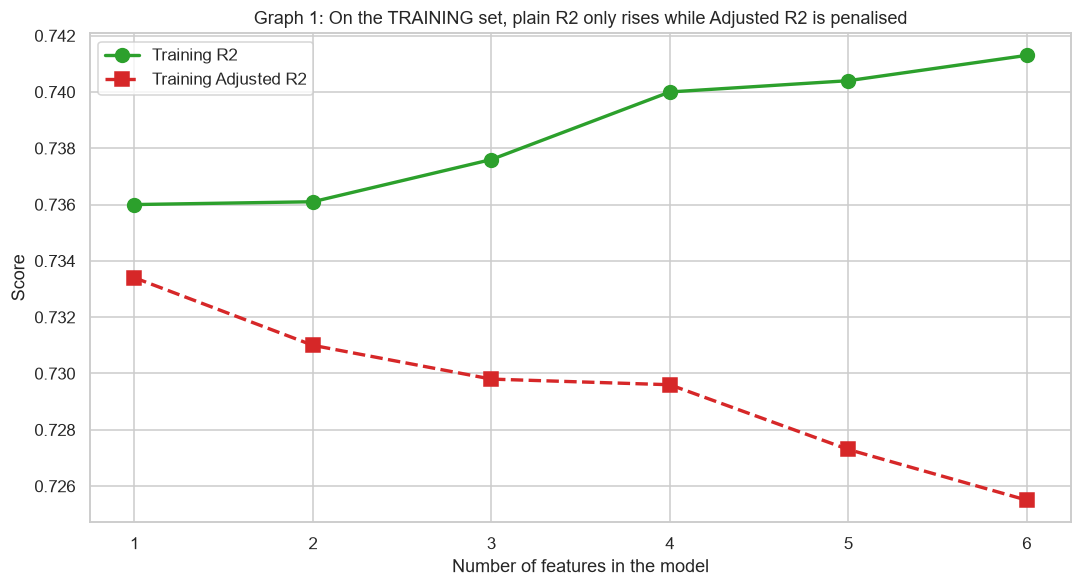

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(results['n_features'], results['train_r2'],
        marker='o', markersize=9, linewidth=2.2, color='#2ca02c', label='Training R2')
ax.plot(results['n_features'], results['train_adj_r2'],
        marker='s', markersize=9, linewidth=2.2, linestyle='--', color='#d62728',
        label='Training Adjusted R2')

ax.set_xlabel('Number of features in the model')
ax.set_ylabel('Score')
ax.set_title('Graph 1: On the TRAINING set, plain R2 only rises while Adjusted R2 is penalised')
ax.set_xticks(results['n_features'])
ax.legend(loc='best')
plt.tight_layout()
plt.show()

**What Graph 1 shows**

The green line (training R2) is flat or gently rising - it is mathematically forbidden from falling. The red dashed line (Adjusted R2) bends downward as junk features pile up.

* **Why training R2 stays the same or increases:** the bigger model can always imitate the smaller one by setting the new coefficient to `0`, so OLS can never do worse on the data it was fitted to.
* **Why Adjusted R2 can decrease:** the gain in R2 from a random feature is tiny, while the `(n-1)/(n-k-1)` penalty is fixed and unavoidable. Junk features cost more than they earn.
* **Practical lesson:** the gap between the two lines is a direct visual measure of how much complexity you are paying for without getting anything back.

### Graph 2: Test R2 vs Test Adjusted R2

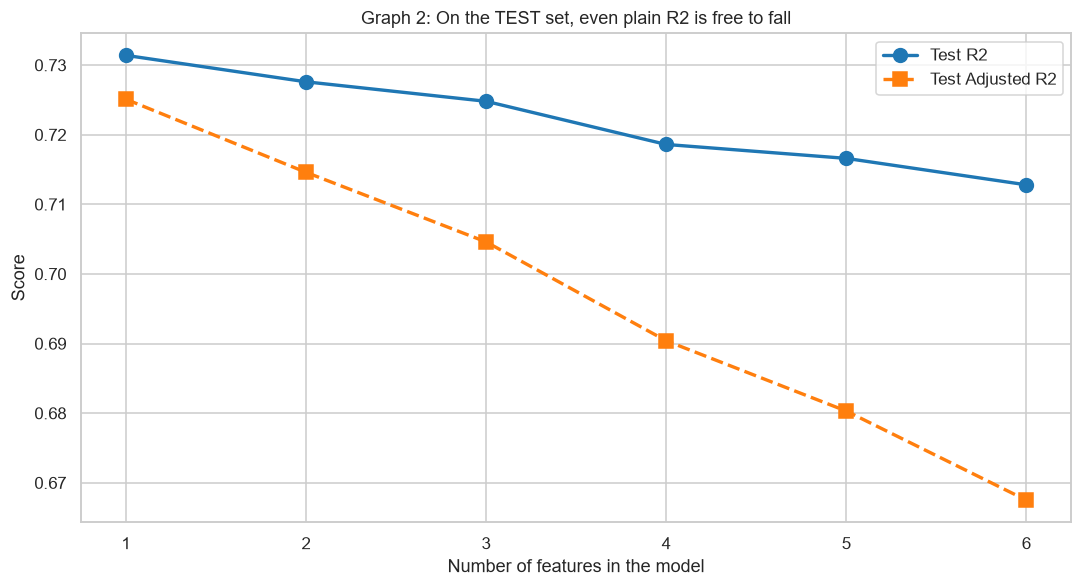

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(results['n_features'], results['test_r2'],
        marker='o', markersize=9, linewidth=2.2, color='#1f77b4', label='Test R2')
ax.plot(results['n_features'], results['test_adj_r2'],
        marker='s', markersize=9, linewidth=2.2, linestyle='--', color='#ff7f0e',
        label='Test Adjusted R2')

ax.set_xlabel('Number of features in the model')
ax.set_ylabel('Score')
ax.set_title('Graph 2: On the TEST set, even plain R2 is free to fall')
ax.set_xticks(results['n_features'])
ax.legend(loc='best')
plt.tight_layout()
plt.show()

**What Graph 2 shows**

Both lines drift downward as junk features are added.

* **Why test performance may decrease:** the "no-decrease" guarantee only holds on the *training* data, because that is the data OLS optimised. Test rows are brand new. The small coefficients the model gave to random features were tuned to training-set noise, and on new data those coefficients just inject error.
* **How irrelevant features cause overfitting:** each extra coefficient is one more knob the model can twist to chase noise. More knobs means the model fits the *specific sample* more closely and the *underlying rule* less faithfully.
* **Why a rise in training R2 does not mean the model improved:** Graph 1 went up while Graph 2 went down - the same features that "helped" on training data actively hurt on unseen data.

### Graph 3: Training R2 vs Test R2 for every model

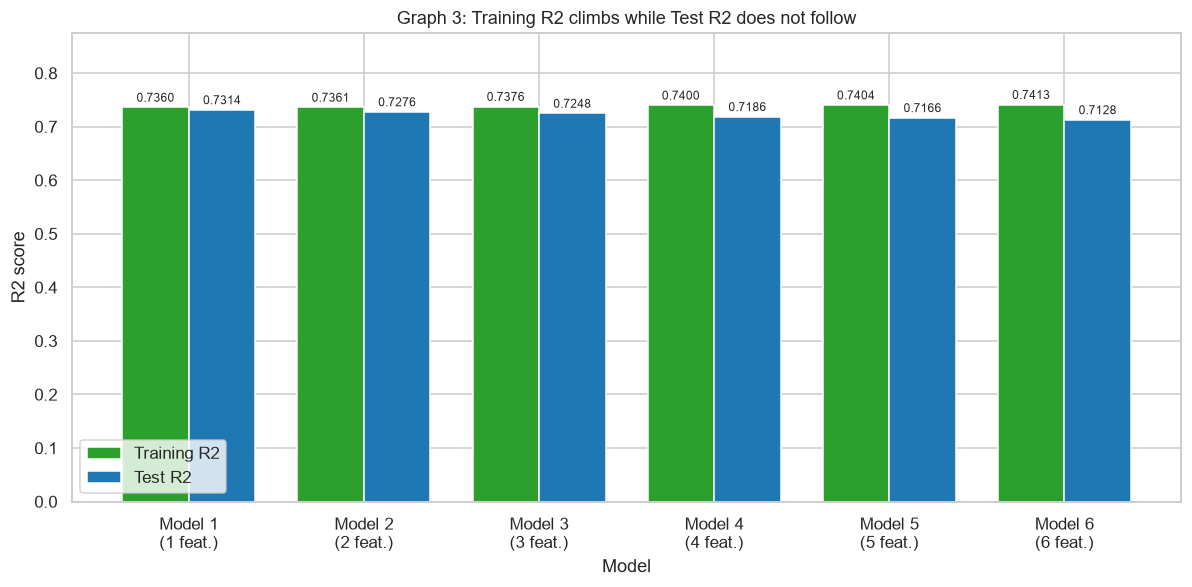

In [14]:
x_positions = np.arange(len(results))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
bars_train = ax.bar(x_positions - bar_width / 2, results['train_r2'], bar_width,
                    color='#2ca02c', label='Training R2')
bars_test = ax.bar(x_positions + bar_width / 2, results['test_r2'], bar_width,
                   color='#1f77b4', label='Test R2')

for bar_group in (bars_train, bars_test):
    ax.bar_label(bar_group, fmt='%.4f', padding=2, fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels([f'{m}\n({k} feat.)' for m, k in zip(results['model'], results['n_features'])])
ax.set_xlabel('Model')
ax.set_ylabel('R2 score')
ax.set_title('Graph 3: Training R2 climbs while Test R2 does not follow')
ax.set_ylim(0, max(results['train_r2'].max(), results['test_r2'].max()) * 1.18)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

**What Graph 3 shows**

Green bars (training) creep upward from left to right; blue bars (test) do not keep up and usually sag.

The **gap between the green and blue bar** is the honest measure of how much the model is fooling itself. A small gap means the model learned a real pattern; a growing gap means it is memorising noise. This is why we always hold out a test set instead of trusting the training score.

### Graph 4: Training RMSE vs Test RMSE for every model

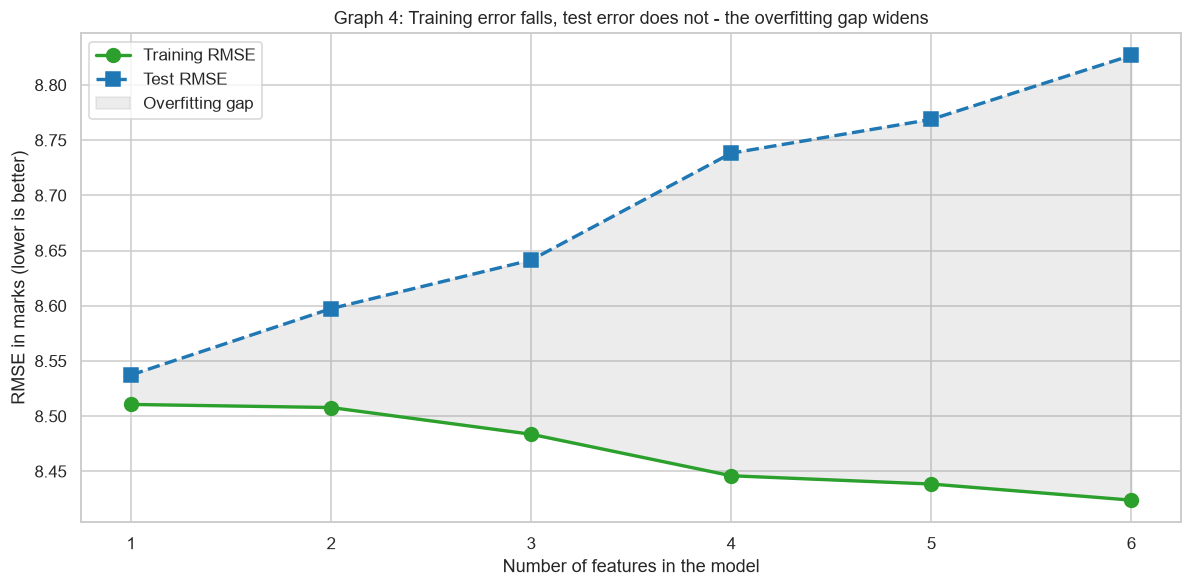

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(results['n_features'], results['train_rmse'],
        marker='o', markersize=9, linewidth=2.2, color='#2ca02c', label='Training RMSE')
ax.plot(results['n_features'], results['test_rmse'],
        marker='s', markersize=9, linewidth=2.2, linestyle='--', color='#1f77b4',
        label='Test RMSE')

ax.fill_between(results['n_features'], results['train_rmse'], results['test_rmse'],
                color='grey', alpha=0.15, label='Overfitting gap')

ax.set_xlabel('Number of features in the model')
ax.set_ylabel('RMSE in marks (lower is better)')
ax.set_title('Graph 4: Training error falls, test error does not - the overfitting gap widens')
ax.set_xticks(results['n_features'])
ax.legend(loc='best')
plt.tight_layout()
plt.show()

**What Graph 4 shows**

RMSE (Root Mean Squared Error) is measured in the same units as `marks`, so it is easier to interpret than R2: "on average we are off by this many marks".

* Training RMSE **always falls** (it is the exact quantity OLS minimises, and it is the mirror image of training R2 rising).
* Test RMSE **rises or stalls**, because the extra coefficients add noise rather than signal on new students.
* The shaded area is the **overfitting gap**. A model that generalises well keeps this area thin.

### Graph 5: Coefficients of the final model

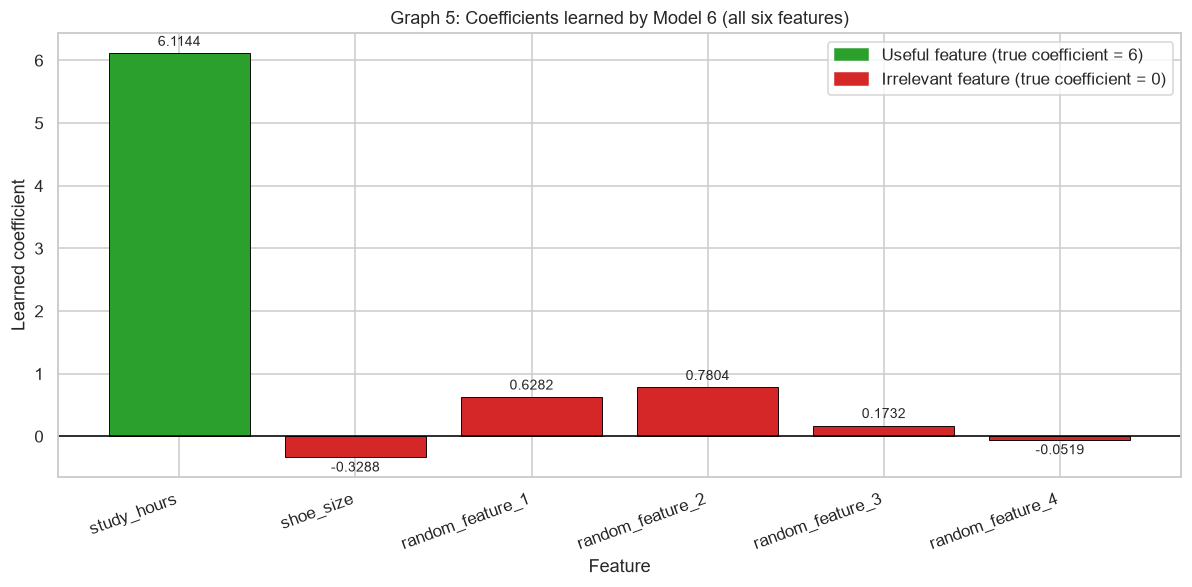

,feature,kind,coefficient
0,study_hours,Useful,6.1144
1,shoe_size,Irrelevant,-0.3288
2,random_feature_1,Irrelevant,0.6282
3,random_feature_2,Irrelevant,0.7804
4,random_feature_3,Irrelevant,0.1732
5,random_feature_4,Irrelevant,-0.0519


Intercept: 35.9256  (true value used to build the data: 30)


In [16]:
final_model, final_features = fitted_models[final_model_name]

coef_df = pd.DataFrame({
    'feature': final_features,
    'coefficient': final_model.coef_,
})
coef_df['kind'] = np.where(coef_df['feature'].isin(USEFUL_FEATURES), 'Useful', 'Irrelevant')

colors = ['#2ca02c' if kind == 'Useful' else '#d62728' for kind in coef_df['kind']]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(coef_df['feature'], coef_df['coefficient'],
              color=colors, edgecolor='black', linewidth=0.6)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.axhline(0, color='black', linewidth=1)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color='#2ca02c', label='Useful feature (true coefficient = 6)'),
    plt.Rectangle((0, 0), 1, 1, color='#d62728', label='Irrelevant feature (true coefficient = 0)'),
]
ax.legend(handles=legend_handles, loc='upper right')

ax.set_xlabel('Feature')
ax.set_ylabel('Learned coefficient')
ax.set_title(f'Graph 5: Coefficients learned by {final_model_name} (all six features)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

display(coef_df[['feature', 'kind', 'coefficient']].round(4))
print(f'Intercept: {final_model.intercept_:.4f}  (true value used to build the data: 30)')

**What Graph 5 shows**

* `study_hours` gets a large coefficient very close to the true value of **6** - the model found the real signal.
* Every irrelevant feature gets a coefficient that is **small but not exactly zero**. This is the heart of the whole notebook.

If the model were perfectly honest it would set those coefficients to exactly `0`. It does not, because in a finite sample each random column happens to overlap slightly with the leftover residual noise, and OLS greedily exploits that overlap to squeeze the training error down.

**Those small non-zero numbers are the mechanism by which training R2 goes up.** They are also the reason test performance gets worse: on new students those coefficients multiply fresh random numbers and add pure error to the prediction.

### Graph 6: Correlation heatmap

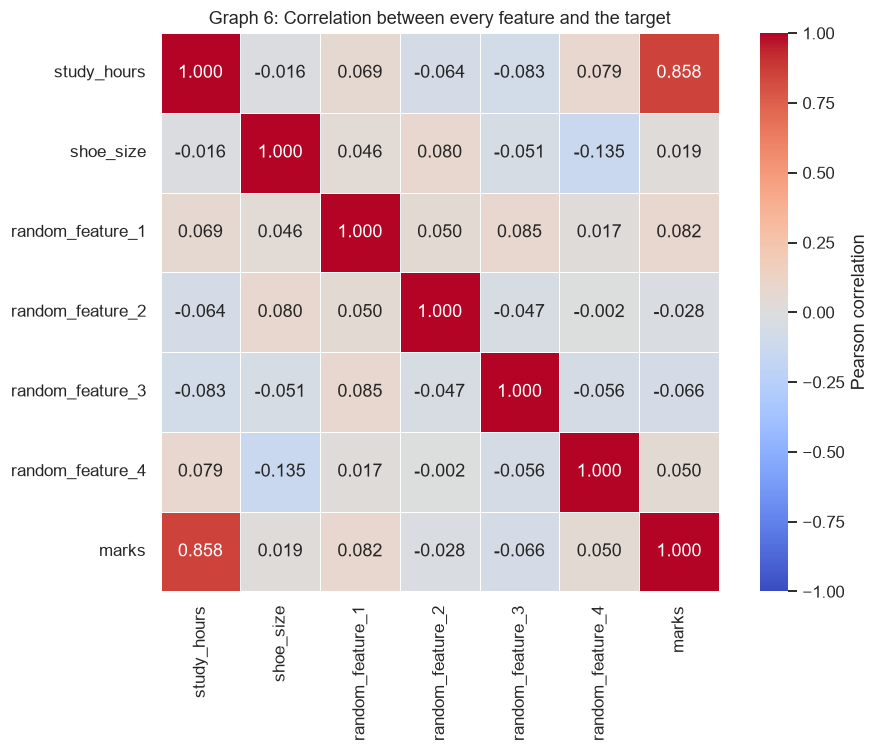

Correlation of each feature with the target:
  USEFUL      study_hours         0.8580
  irrelevant  shoe_size           0.0190
  irrelevant  random_feature_1    0.0821
  irrelevant  random_feature_2   -0.0282
  irrelevant  random_feature_3   -0.0664
  irrelevant  random_feature_4    0.0499


In [17]:
corr_matrix = df[ALL_FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.6, linecolor='white',
            square=True, cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Graph 6: Correlation between every feature and the target')
plt.tight_layout()
plt.show()

print('Correlation of each feature with the target:')
for feature in ALL_FEATURES:
    tag = 'USEFUL    ' if feature in USEFUL_FEATURES else 'irrelevant'
    print(f'  {tag}  {feature:<18} {corr_matrix.loc[feature, TARGET]: .4f}')

**What Graph 6 shows**

* `study_hours` vs `marks` shows a strong positive correlation (roughly 0.8) - a genuine, strong relationship.
* Every irrelevant feature vs `marks` shows a correlation close to `0`, but **never exactly `0`**. Values like `0.05` or `-0.09` appear purely by chance.

That tiny accidental correlation is exactly what linear regression grabs onto. With only 150 rows, random numbers *always* look slightly related to something. With millions of rows these correlations would shrink towards zero and the effect would nearly vanish - which is why **small datasets are the most dangerous place to trust training R2**.

### Seeing overfitting with your own eyes: a LINE in 2D vs a PLANE in 3D

So far we have only read numbers in a table. Now let us actually **look** at the geometry, because the reason training R2 cannot go down is a *shape* argument, not a formula argument.

| Features the model can see | The shape it fits | Where it lives |
|---|---|---|
| `study_hours` | a straight **line** | a 2D picture (x = study_hours, y = marks) |
| `study_hours` + `shoe_size` | a flat **plane** | a 3D picture (x, y = the two features, z = marks) |

The key idea:

> A **plane can always choose to be flat**. If it sets the `shoe_size` slope to `0`, it becomes an exact copy of the line. So the plane starts with every option the line had - plus the option to **tilt**.
>
> Since `shoe_size` is pure noise, tilting cannot capture any real pattern. But in a small sample there is *always* a tilt that happens to hug these particular points a bit better. Least squares takes it, the errors shrink, and training R2 rises.

To make the tilt easy to see, we zoom in on just **14 training students**.

In [18]:
# A deliberately TINY training set (14 students) so the effect is big enough to see by eye.
N_DEMO = 14
demo_X = X_train[['study_hours', 'shoe_size']].iloc[:N_DEMO]
demo_y = y_train.iloc[:N_DEMO]

x1 = demo_X['study_hours'].to_numpy()   # the useful feature
x2 = demo_X['shoe_size'].to_numpy()     # the irrelevant feature
y_true = demo_y.to_numpy()

# Model A - one feature. The fitted shape is a LINE living in a 2D world.
model_a = LinearRegression().fit(demo_X[['study_hours']], demo_y)
pred_a = model_a.predict(demo_X[['study_hours']])

# Model B - two features. The fitted shape is a PLANE living in a 3D world.
model_b = LinearRegression().fit(demo_X[['study_hours', 'shoe_size']], demo_y)
pred_b = model_b.predict(demo_X[['study_hours', 'shoe_size']])

resid_a = y_true - pred_a               # how far each point sits from the line
resid_b = y_true - pred_b               # how far each point sits from the plane

sse_a = float(np.sum(resid_a ** 2))     # sum of squared errors = what OLS minimises
sse_b = float(np.sum(resid_b ** 2))
r2_a = r2_score(y_true, pred_a)
r2_b = r2_score(y_true, pred_b)

demo_summary = pd.DataFrame({
    'model': ['A: study_hours only', 'B: study_hours + shoe_size'],
    'n_features': [1, 2],
    'fitted_shape': ['line in 2D', 'plane in 3D'],
    'train_SSE': [sse_a, sse_b],
    'train_r2': [r2_a, r2_b],
    'train_adj_r2': [adjusted_r2(r2_a, N_DEMO, 1), adjusted_r2(r2_b, N_DEMO, 2)],
})
display(demo_summary.round(4))

print(f'Training SSE went DOWN by {sse_a - sse_b:8.2f}  ({100 * (sse_a - sse_b) / sse_a:.2f}% of the original error)')
print(f'Training R2  went UP   by {r2_b - r2_a:8.4f}')
print(f'Training Adjusted R2 changed by {adjusted_r2(r2_b, N_DEMO, 2) - adjusted_r2(r2_a, N_DEMO, 1):.4f}')
print(f'Coefficient the model gave to the useless shoe_size: {model_b.coef_[1]:.4f}   (the true value is 0)')

,model,n_features,fitted_shape,train_SSE,train_r2,train_adj_r2
0,A: study_hours only,1,line in 2D,939.9195,0.7214,0.6982
1,B: study_hours + shoe_size,2,plane in 3D,888.9825,0.7365,0.6886


Training SSE went DOWN by    50.94  (5.42% of the original error)
Training R2  went UP   by   0.0151
Training Adjusted R2 changed by -0.0096
Coefficient the model gave to the useless shoe_size: -1.5622   (the true value is 0)


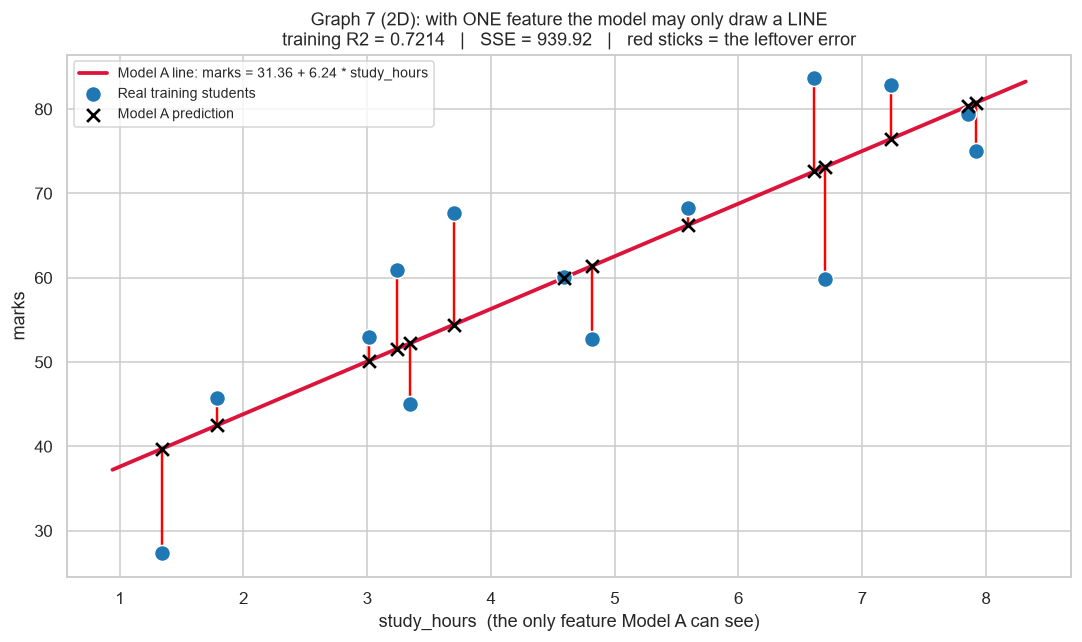

In [19]:
grid = np.linspace(x1.min() - 0.4, x1.max() + 0.4, 100)
line_a = model_a.intercept_ + model_a.coef_[0] * grid

fig, ax = plt.subplots(figsize=(10, 6))

# Red sticks = the training error left over for each student.
for xi, yi, pi in zip(x1, y_true, pred_a):
    ax.plot([xi, xi], [yi, pi], color='red', linewidth=1.6, zorder=1)

ax.plot(grid, line_a, color='crimson', linewidth=2.5, zorder=2,
        label=f'Model A line: marks = {model_a.intercept_:.2f} + {model_a.coef_[0]:.2f} * study_hours')
ax.scatter(x1, y_true, s=110, color='#1f77b4', edgecolor='white', zorder=3,
           label='Real training students')
ax.scatter(x1, pred_a, s=70, marker='x', color='black', linewidth=1.8, zorder=4,
           label='Model A prediction')

ax.set_xlabel('study_hours  (the only feature Model A can see)')
ax.set_ylabel('marks')
ax.set_title('Graph 7 (2D): with ONE feature the model may only draw a LINE\n'
             f'training R2 = {r2_a:.4f}   |   SSE = {sse_a:.2f}   |   red sticks = the leftover error')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**What Graph 7 shows**

This is the **2D world** of Model A. It can see only `study_hours`, so the best it can ever draw is a **straight line**.

The **red sticks** are the training errors: the vertical distance from each real student (blue dot) down or up to the model's prediction (black cross). `SSE` is the sum of the squared lengths of those sticks, and R2 is just that number rescaled.

The line is already the *best possible* line - no other line makes the sticks shorter. To do better, the model needs a **new direction to move in**. That is exactly what a second feature provides, and it is what the next graph shows.

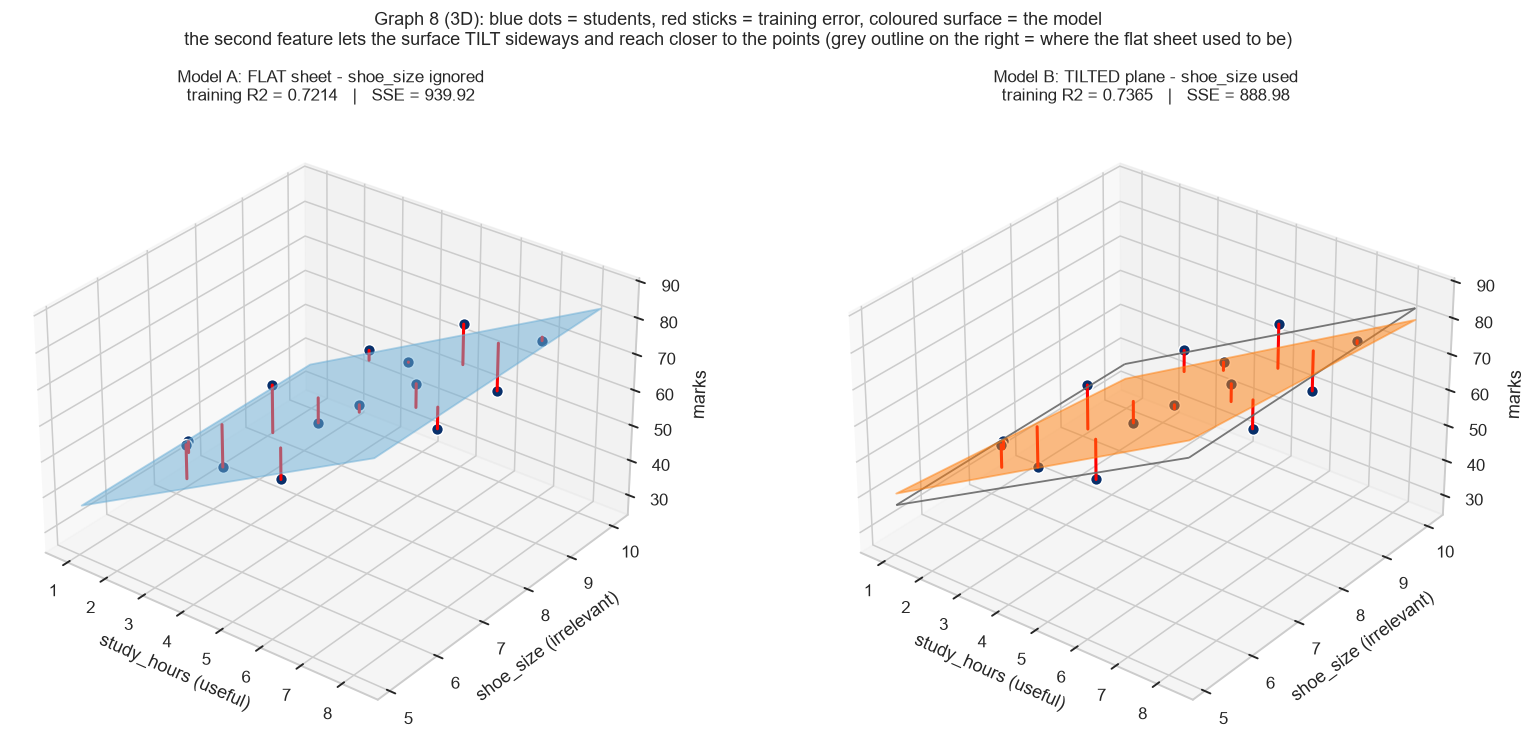

In [20]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  - registers the '3d' projection

# Both models are flat surfaces, so a 2x2 grid over the (study_hours, shoe_size) floor
# is all we need to draw them as a single clean sheet.
g1 = np.linspace(x1.min() - 0.4, x1.max() + 0.4, 2)
g2 = np.linspace(x2.min() - 0.4, x2.max() + 0.4, 2)
G1, G2 = np.meshgrid(g1, g2)

# Model A never saw shoe_size, so its surface is FLAT along the shoe_size axis.
ZA = model_a.intercept_ + model_a.coef_[0] * G1
# Model B has a shoe_size coefficient, so its surface is allowed to TILT sideways.
ZB = model_b.intercept_ + model_b.coef_[0] * G1 + model_b.coef_[1] * G2

# Identical z-limits in both panels, otherwise the red sticks cannot be compared by eye.
z_low = min(y_true.min(), ZA.min(), ZB.min()) - 3
z_high = max(y_true.max(), ZA.max(), ZB.max()) + 3

panels = [
    (ZA, pred_a, sse_a, r2_a, '#6baed6', 'Model A: FLAT sheet - shoe_size ignored'),
    (ZB, pred_b, sse_b, r2_b, '#ff7f0e', 'Model B: TILTED plane - shoe_size used'),
]

fig = plt.figure(figsize=(15, 7))
for i, (Z, pred, sse, r2, color, title) in enumerate(panels, start=1):
    ax = fig.add_subplot(1, 2, i, projection='3d')

    # On the right, keep a faint outline of the flat sheet so the tilt is obvious.
    if i == 2:
        ax.plot_wireframe(G1, G2, ZA, color='dimgrey', linewidth=1.2, alpha=0.9)

    ax.plot_surface(G1, G2, Z, color=color, alpha=0.5, shade=False,
                    edgecolor=color, linewidth=1.2)

    # Red sticks = the training error of each student, measured vertically to the surface.
    for xi, si, yi, pi in zip(x1, x2, y_true, pred):
        ax.plot([xi, xi], [si, si], [yi, pi], color='red', linewidth=2.0)

    ax.scatter(x1, x2, y_true, s=60, color='#08306b', edgecolor='white', depthshade=False)

    ax.set_xlabel('study_hours (useful)')
    ax.set_ylabel('shoe_size (irrelevant)')
    ax.set_zlabel('marks')
    ax.set_zlim(z_low, z_high)
    ax.set_box_aspect((1, 1, 0.65))
    ax.view_init(elev=30, azim=-52)
    ax.set_title(f'{title}\ntraining R2 = {r2:.4f}   |   SSE = {sse:.2f}', fontsize=11, pad=0)

fig.suptitle('Graph 8 (3D): blue dots = students, red sticks = training error, coloured surface = the model\n'
             'the second feature lets the surface TILT sideways and reach closer to the points '
             '(grey outline on the right = where the flat sheet used to be)',
             fontsize=12)
plt.tight_layout()
plt.show()

**What Graph 8 shows**

Both pictures contain **exactly the same blue points** and **exactly the same red error sticks** are measured the same way. Only the grey/orange surface changed.

* **Left - Model A.** `shoe_size` is ignored, so the surface is a **flat sheet**: move sideways along the `shoe_size` axis and the predicted marks do not change at all. It is literally the 2D line from Graph 7, stretched out into the third dimension.
* **Right - Model B.** `shoe_size` now has a coefficient, so the sheet is allowed to **tilt sideways**. Least squares tilts it in whatever direction makes the red sticks shortest *for these particular students*.

Compare the red sticks: on the right they are shorter. Shorter sticks = smaller SSE = **higher training R2**. The model did not become smarter - it just gained the freedom to lean.

Let us measure that shortening point by point.

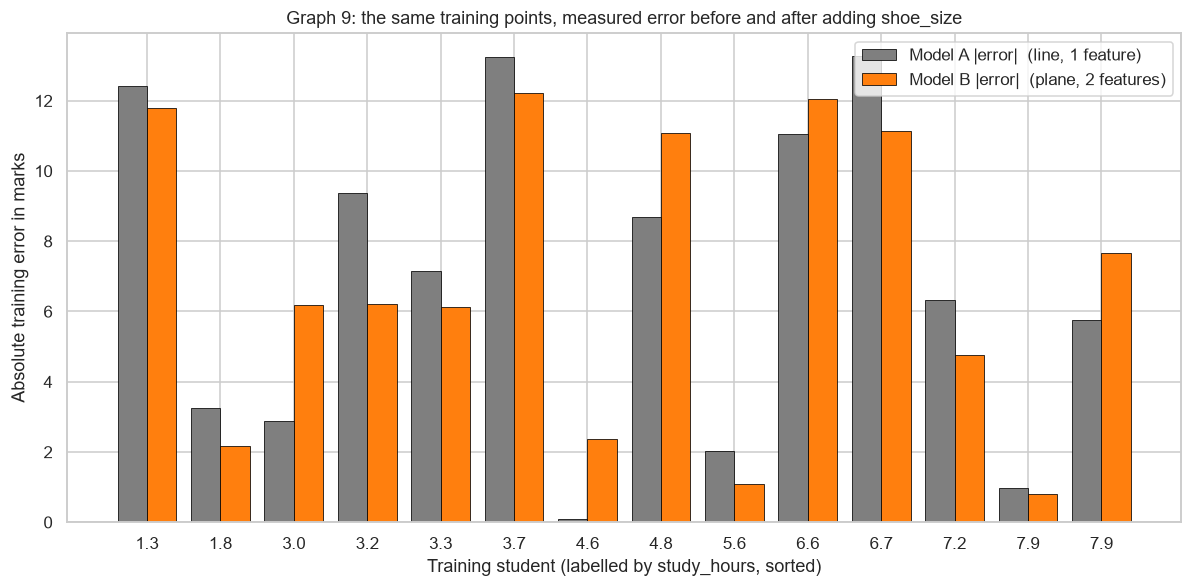

Mean |error|, Model A (line) : 6.8956 marks
Mean |error|, Model B (plane): 6.8338 marks
9 of the 14 training points moved CLOSER to the prediction surface.
The TOTAL squared error is guaranteed to shrink, even if an individual point gets slightly worse.


In [21]:
order = np.argsort(x1)
positions = np.arange(N_DEMO)
width = 0.40

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(positions - width / 2, np.abs(resid_a)[order], width,
       color='#7f7f7f', edgecolor='black', linewidth=0.5,
       label='Model A |error|  (line, 1 feature)')
ax.bar(positions + width / 2, np.abs(resid_b)[order], width,
       color='#ff7f0e', edgecolor='black', linewidth=0.5,
       label='Model B |error|  (plane, 2 features)')

ax.set_xticks(positions)
ax.set_xticklabels([f'{v:.1f}' for v in x1[order]])
ax.set_xlabel('Training student (labelled by study_hours, sorted)')
ax.set_ylabel('Absolute training error in marks')
ax.set_title('Graph 9: the same training points, measured error before and after adding shoe_size')
ax.legend()
plt.tight_layout()
plt.show()

improved = int(np.sum(np.abs(resid_b) < np.abs(resid_a)))
print(f'Mean |error|, Model A (line) : {np.abs(resid_a).mean():.4f} marks')
print(f'Mean |error|, Model B (plane): {np.abs(resid_b).mean():.4f} marks')
print(f'{improved} of the {N_DEMO} training points moved CLOSER to the prediction surface.')
print('The TOTAL squared error is guaranteed to shrink, even if an individual point gets slightly worse.')

**Takeaway from Graphs 7, 8 and 9**

The extra dimension is the whole trick.

* With **1 feature** the model lives in a 2D world and the only shape it can draw is a **line**. Its freedom is 2 numbers: intercept and slope.
* With **2 features** the model lives in a 3D world and the shape becomes a **plane**. Its freedom is 3 numbers: intercept and two slopes.
* The plane **can always choose to stay flat** (`shoe_size` coefficient = `0`), which reproduces the line exactly. So it can never be forced into a worse training fit - this is the geometric picture of "training R2 cannot decrease".
* Because `shoe_size` is random, the flat option is *almost never* the exact best one for this particular sample. A slight tilt always reaches a few points a bit better, so least squares tilts, the total squared error drops, and **training R2 goes up**.

But that tilt was fitted to **these 14 students' noise**. A new student with a different shoe size gets pushed up or down by a rule that does not exist in reality - which is exactly how the test score gets worse while the training score looks better. That is overfitting, seen with your own eyes.

## 8. Repeated experiment - proving it was not a fluke

One dataset could be lucky. To show this is a *systematic* effect rather than a coincidence, we repeat the entire experiment **300 times**, each time with a brand-new random seed (so brand-new data and brand-new junk features).

In every repetition we compare:

* **Model A** - `study_hours` only.
* **Model B** - `study_hours` + 5 irrelevant features.

and record three differences (B minus A):

1. change in **training R2**,
2. change in **training Adjusted R2**,
3. change in **test R2**.

In [22]:
def run_one_experiment(seed, n_samples=150, n_irrelevant=5, test_size=0.30):
    """Build a fresh dataset with the given seed and compare Model A with Model B."""
    local_rng = np.random.default_rng(seed)

    # Fresh data, same true rule as before.
    hours = local_rng.uniform(1.0, 10.0, n_samples)
    target = 30 + 6 * hours + local_rng.normal(0.0, 8.0, n_samples)

    # Fresh irrelevant features - never used to build `target`.
    junk = local_rng.normal(0.0, 1.0, size=(n_samples, n_irrelevant))

    X_useful = hours.reshape(-1, 1)                  # Model A inputs
    X_all = np.column_stack([hours, junk])           # Model B inputs

    # One split per repetition, shared by both models so the comparison is fair.
    idx_train, idx_test = train_test_split(
        np.arange(n_samples), test_size=test_size, random_state=seed
    )
    y_tr, y_te = target[idx_train], target[idx_test]
    n_tr = len(idx_train)

    scores = {}
    for label, matrix in (('A', X_useful), ('B', X_all)):
        k = matrix.shape[1]
        mdl = LinearRegression().fit(matrix[idx_train], y_tr)
        tr_r2 = r2_score(y_tr, mdl.predict(matrix[idx_train]))
        te_r2 = r2_score(y_te, mdl.predict(matrix[idx_test]))
        scores[label] = (tr_r2, adjusted_r2(tr_r2, n_tr, k), te_r2)

    return {
        'seed': seed,
        'delta_train_r2': scores['B'][0] - scores['A'][0],
        'delta_train_adj_r2': scores['B'][1] - scores['A'][1],
        'delta_test_r2': scores['B'][2] - scores['A'][2],
    }


N_EXPERIMENTS = 300
experiments = pd.DataFrame([run_one_experiment(seed) for seed in range(N_EXPERIMENTS)])

print(f'Completed {N_EXPERIMENTS} independent experiments.')
display(experiments.head(10).round(4))
display(experiments[['delta_train_r2', 'delta_train_adj_r2', 'delta_test_r2']].describe().round(4))

Completed 300 independent experiments.


,seed,delta_train_r2,delta_train_adj_r2,delta_test_r2
0,0,0.0158,0.0060,-0.0135
1,1,0.0052,-0.0053,0.0100
2,2,0.0022,-0.0093,-0.0116
3,3,0.0029,-0.0077,-0.0066
4,4,0.0218,0.0114,-0.0047
5,5,0.0092,-0.0019,-0.0100
6,6,0.0206,0.0094,-0.0385
7,7,0.0138,0.0049,0.0088
8,8,0.0154,0.0038,-0.0436
9,9,0.0056,-0.0030,0.0081


,delta_train_r2,delta_train_adj_r2,delta_test_r2
count,300.0000,300.0000,300.0000
mean,0.0104,0.0003,-0.0137
std,0.0067,0.0068,0.0201
min,0.0004,-0.0130,-0.0906
25%,0.0054,-0.0045,-0.0264
50%,0.0092,-0.0009,-0.0098
75%,0.0137,0.0040,0.0013
max,0.0392,0.0310,0.0364


In [23]:
# How often did each effect happen? (A tiny tolerance guards against float rounding.)
TOL = 1e-12

pct_train_r2_up = (experiments['delta_train_r2'] > TOL).mean() * 100
pct_train_r2_down = (experiments['delta_train_r2'] < -TOL).mean() * 100
pct_adj_r2_down = (experiments['delta_train_adj_r2'] < -TOL).mean() * 100
pct_test_r2_down = (experiments['delta_test_r2'] < -TOL).mean() * 100

print(f'Out of {N_EXPERIMENTS} experiments with 5 purely random extra features:')
print('-' * 70)
print(f'Training R2 INCREASED          : {pct_train_r2_up:6.2f}% of the time')
print(f'Training R2 DECREASED          : {pct_train_r2_down:6.2f}% of the time  <- mathematically impossible')
print(f'Training Adjusted R2 DECREASED : {pct_adj_r2_down:6.2f}% of the time')
print(f'Test R2 DECREASED              : {pct_test_r2_down:6.2f}% of the time')
print('-' * 70)
print(f"Average change in training R2          : {experiments['delta_train_r2'].mean(): .5f}")
print(f"Average change in training Adjusted R2 : {experiments['delta_train_adj_r2'].mean(): .5f}")
print(f"Average change in test R2              : {experiments['delta_test_r2'].mean(): .5f}")

Out of 300 experiments with 5 purely random extra features:
----------------------------------------------------------------------
Training R2 INCREASED          : 100.00% of the time
Training R2 DECREASED          :   0.00% of the time  <- mathematically impossible
Training Adjusted R2 DECREASED :  55.00% of the time
Test R2 DECREASED              :  71.67% of the time
----------------------------------------------------------------------
Average change in training R2          :  0.01039
Average change in training Adjusted R2 :  0.00032
Average change in test R2              : -0.01368


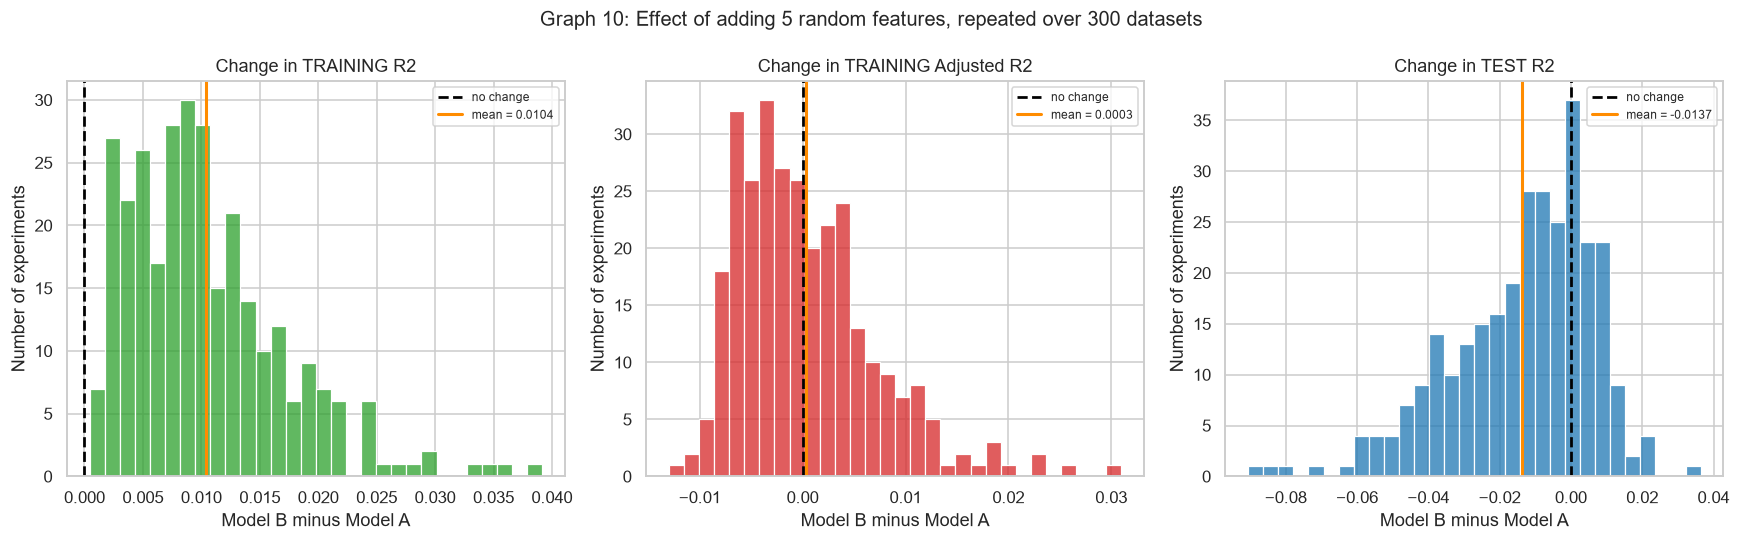

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_specs = [
    ('delta_train_r2', 'Change in TRAINING R2', '#2ca02c'),
    ('delta_train_adj_r2', 'Change in TRAINING Adjusted R2', '#d62728'),
    ('delta_test_r2', 'Change in TEST R2', '#1f77b4'),
]

for ax, (column, title, color) in zip(axes, plot_specs):
    sns.histplot(experiments[column], bins=30, color=color, edgecolor='white', ax=ax)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.8, label='no change')
    ax.axvline(experiments[column].mean(), color='darkorange', linestyle='-', linewidth=2,
               label=f'mean = {experiments[column].mean():.4f}')
    ax.set_title(title)
    ax.set_xlabel('Model B minus Model A')
    ax.set_ylabel('Number of experiments')
    ax.legend(fontsize=8)

fig.suptitle(f'Graph 10: Effect of adding 5 random features, repeated over {N_EXPERIMENTS} datasets',
             fontsize=13)
plt.tight_layout()
plt.show()

## 9. Explanation of the repeated experiment

**What the histograms show**

* **Left (training R2):** every single bar sits to the **right of zero**. Across all 300 datasets, training R2 *never once* decreased. That is not luck - it is the nested-OLS guarantee. The average gain is small and positive: junk features always "help", just barely.
* **Middle (training Adjusted R2):** the distribution is now spread across zero and its average is almost exactly `0`. Adjusted R2 falls in **more than half** of the experiments, and its median is negative - the penalty has cancelled out nearly all of the fake gain we saw on the left. Plain R2 said "always better"; Adjusted R2 says "usually not worth it".
* **Right (test R2):** centred clearly **below zero** and much more spread out. On unseen data the junk features are a gamble that is biased against you - occasionally they help by accident, far more often they hurt.

**Why training R2 stays the same or increases:** the larger model contains the smaller model as a special case (set the new coefficients to `0`), so least squares can never end up with a worse training fit.

**Why Adjusted R2 can decrease:** it explicitly charges for complexity. A feature must deliver a real improvement to survive that charge; random noise usually cannot.

**Why test performance may decrease:** coefficients fitted to this sample's noise are meaningless for new data, so they add error instead of removing it.

**How irrelevant features cause overfitting:** each one adds a free parameter that the model uses to bend towards individual training points. The model ends up describing the *sample* instead of the *population*.

**Why an increase in training R2 does not automatically mean the model improved:** the left histogram (always positive) and the right histogram (usually negative) come from the *same* experiments. Training R2 went up while real-world accuracy went down. Training R2 rising is therefore **not evidence of a better model** - it is only evidence that the model has more freedom.

## 10. Final conclusion

### The seven points to remember

1. **Extra features give a regression model more flexibility.** Every new column is one more knob the model can turn while fitting the training data.

2. **The old model is still possible**, because the coefficient of a new feature can simply be `0`. The bigger model therefore has every option the smaller one had, plus more.

3. **Therefore training R2 cannot decrease** for nested ordinary least squares models evaluated on the same data. It stays flat or goes up - never down. Our 300 repetitions confirmed this without a single exception.

4. **A random feature may fit noise and slightly increase training R2.** In a finite sample, random numbers always show a small accidental correlation with the leftover residuals, and OLS takes the free lunch.

5. **Adjusted R2 penalises unnecessary features.** The `(n-1)/(n-k-1)` term makes every feature pay rent. Junk features cannot pay, so Adjusted R2 drops.

6. **Test-set performance tells you whether the new feature generalises.** The test rows never influenced the coefficients, so there is no accidental pattern for the model to exploit. This is the honest exam.

7. **Never judge a feature's usefulness from training R2 alone.** Use Adjusted R2, a held-out test set, cross-validation, domain knowledge, and simple common sense (shoe size does not cause exam marks).

---

### One-line summary for the classroom

> **A higher training R2 means the model fits the data you already have. Only a higher test score means the model understands the problem.**